In [1]:
import sys
sys.path.insert(0, '../') 
import data_generation.SimulatorWaveEquation as simu
import numpy as np
from data_generation import DataPlotter as dp
import matplotlib.pyplot as plt
import os 
import GNN_model_startup.GNN as gnn
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader as PyGDataLoader
import torch.nn as nn
import pytorch_lightning as pl
import GNN_model_startup.autoregreesive_roll_out as autoregreesive_roll_out
import GNN_model_startup.onestep_rollout as onestep_rollout
import xarray as xr

c:\Users\maria\OneDrive - Danmarks Tekniske Universitet\Kandidat\Masters\code_masters\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Data set up

In [4]:
R = 1 # Radius
C = 1 # Wave speed
Lmax = 20 # Maximum degree of spherical harmonics
tmax = 10 # Maximum time  
generations = 4 # level of refinement for the grid
x0,y0,z0 = R,R,R # Initial position of the gaussian pulse
omega = C/R*np.sqrt(Lmax*(Lmax+1)) 
T_period = 2*np.pi/omega
dt = T_period/10 # Time step 
print("dt =", dt)

# Initial condition: Gaussian pulse centered at (x0, y0, z0)
def f_handle(x, y, z):
    # dot product with center
    dot = x*x0 + y*y0 + z*z0
    
    cos_alpha = np.clip(dot / R**2, -1.0, 1.0)

    alpha = np.arccos(cos_alpha)
     
    return np.exp(-(alpha**2) / (2*0.2**2))

# Initital condition: zero initial velocity
g_handle = lambda x, y, z: 0 * x

dt = 0.030658804998128553


In [ ]:
sim = simu.SimulatorWaveEquation(R=1.0, C=C, Lmax=Lmax, tmax=tmax, f_handle=f_handle, g_handle=g_handle, generations=generations,dt=0.01)
print("clf val:",sim.clf_value)
print("dt:",sim.dt)
print("dx:",sim.dx)

clf val: 7.0035038109375805
dt: 0.01
dx: 0.07003503810937581


In [40]:
title = f"different_clf/wave_sphere_data_clf{sim.clf_value:.2f}"
ds = sim.simulate(title=title, savedata=True, savegraph=False)  # (time, N) 

## Training data with different clf condition

In [44]:

titles = ["wave_sphere_data_clf0.10.nc",
          "wave_sphere_data_clf0.23.nc",
          "wave_sphere_data_clf0.35.nc",
          "wave_sphere_data_clf0.70.nc",
          "wave_sphere_data_clf0.88.nc",
          "wave_sphere_data_clf1.00.nc",
          "wave_sphere_data_clf1.40.nc",
          "wave_sphere_data_clf1.75.nc",
          "wave_sphere_data_clf7.00.nc"
          ]
nc_path = "../data/nc_files/different_clf"
clf_values = [0.10, 0.23, 0.35, 0.70, 0.88, 1.00, 1.40, 1.75, 7.00]

model = {}
loader = {}
for title, clf in zip(titles, clf_values):
    dataset = gnn.WaveData(data_path=os.path.join(nc_path, f"{title}"))

    # PyG DataLoader batches graphs automatically (no collate_fn needed)
    loader[f"clf_{clf}"] = PyGDataLoader(dataset, batch_size=32, shuffle=True, num_workers=0)

    Fin = 1
    Fm = 64

    phi = nn.Sequential(
        nn.Linear(2 * Fin, Fm),
        nn.ReLU(),
        nn.Linear(Fm, Fm),
    )

    psi = nn.Sequential(
        nn.Linear(Fin + Fm, Fm),
        nn.ReLU(),
        nn.Linear(Fm, Fin),
    )

    model[f"clf_{clf}"] = gnn.GNNModel(phi=phi, psi=psi, aggregate="mean", lr=1e-3)


In [45]:
for clf in clf_values:

    trainer = pl.Trainer(max_epochs=50) 
    trainer.fit(model[f"clf_{clf}"], loader[f"clf_{clf}"],enable_progress_bar=False,logger=False) 
    

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


┏━━━┳━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ phi  │ Sequential │  4.4 K │ train │     0 │
│ 1 │ psi  │ Sequential │  4.3 K │ train │     0 │
└───┴──────┴────────────┴────────┴───────┴───────┘

Trainable params: 8.6 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 8.6 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 8                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

c:\Users\maria\OneDrive - Danmarks Tekniske 
Universitet\Kandidat\Masters\code_masters\.venv\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

c:\Users\maria\OneDrive - Danmarks Tekniske Universitet\Kandidat\Masters\code_masters\.venv\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\Users\maria\OneDrive - Danmarks Tekniske Universitet\Kandidat\Masters\code_masters\.venv\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
c:\Users\maria\OneDrive - Danmarks Tekniske Universitet\Kandidat\Masters\code_masters\.venv\Lib\site-packages\pytorch_lightning\loops\fit_loop.py:317: The number of training batches (1) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
`Trainer.fit` st

...

c:\Users\maria\OneDrive - Danmarks Tekniske Universitet\Kandidat\Masters\code_masters\.venv\Lib\site-packages\pytorch_lightning\loops\fit_loop.py:317: The number of training batches (8) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
`Trainer.fit` stopped: `max_epochs=50` reached.


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


┏━━━┳━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ phi  │ Sequential │  4.4 K │ train │     0 │
│ 1 │ psi  │ Sequential │  4.3 K │ train │     0 │
└───┴──────┴────────────┴────────┴───────┴───────┘

Trainable params: 8.6 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 8.6 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 8                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

c:\Users\maria\OneDrive - Danmarks Tekniske Universitet\Kandidat\Masters\code_masters\.venv\Lib\site-packages\pytorch_lightning\loops\fit_loop.py:317: The number of training batches (32) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
`Trainer.fit` stopped: `max_epochs=50` reached.


In [46]:
def rmse_over_time(ds_pred: xr.Dataset, ds_true: xr.Dataset, steps=None):
    """
    Returns rmse_t(time) as an xarray DataArray, aligned in time length.
    Assumes ds_pred['u'] and ds_true['u'] have dims (time, grid_index).
    """
    # make sure we compare the same number of time steps
    T_true = ds_true.sizes["time"]
    T_pred = ds_pred.sizes["time"]
    T = min(T_true, T_pred)

    if steps is not None:
        T = min(T, steps + 1)  # +1 because rollout includes initial state

    u_pred = ds_pred["u"].isel(time=slice(0, T))
    u_true = ds_true["u"].isel(time=slice(0, T))

    rmse_t = np.sqrt(((u_pred - u_true) ** 2).mean("grid_index"))
    return rmse_t

In [ ]:
import os
import pandas as pd

results = []
rmse_curves = {}  # store full curves if you want to plot later

steps = 200

for title, clf in zip(titles, clf_values):
    # ensure filename ends with .nc
    fname = title if str(title).endswith(".nc") else f"{title}.nc"
    ds = xr.open_dataset(os.path.join(nc_path, fname))

    # rollout with the matching model
    ds_pred = autoregreesive_roll_out.autoregressive_rollout(
        model[f"clf_{clf}"], ds, steps=steps, device="cpu"
    )

    rmse_t = rmse_over_time(ds_pred, ds, steps=steps)
    rmse_curves[(title, clf)] = rmse_t

    # summary stats
    time_vals = rmse_t["time"].values
    rmse_vals = rmse_t.values

    # relative RMSE normalization (optional but useful)
    true_rms_t = np.sqrt((ds["u"].isel(time=slice(0, len(rmse_t))) ** 2).mean("grid_index"))
    rel_rmse_t = rmse_t / true_rms_t.clip(min=1e-12)

    results.append({
        "title": title,
        "clf": float(clf),
        "dt": float(ds.attrs.get("dt", np.nan)),
        "C": float(ds.attrs.get("C", np.nan)),
        "dx": float(ds.attrs.get("dx", np.nan)),
        "rmse_final": float(rmse_vals[-1]),
        "rmse_mean": float(rmse_vals.mean()),
        #"rmse_auc": float(np.trapz(rmse_vals, x=np.arange(len(rmse_vals)))),  # or use time_vals if numeric
        "rel_rmse_final": float(rel_rmse_t.values[-1]),
        "rel_rmse_mean": float(rel_rmse_t.values.mean()),
    })

df = pd.DataFrame(results).sort_values("clf")
df 

,title,clf,dt,C,dx,rmse_final,rmse_mean,rel_rmse_final,rel_rmse_mean
0,wave_sphere_data_clf0.10.nc,0.10,0.70,1.0,0.070035,0.179162,0.256855,0.619606,0.702352
1,wave_sphere_data_clf0.23.nc,0.23,0.30,1.0,0.070035,0.204975,0.278528,0.691161,0.764311
2,wave_sphere_data_clf0.35.nc,0.35,0.20,1.0,0.070035,0.212926,0.277147,0.696504,0.761622
3,wave_sphere_data_clf0.70.nc,0.70,0.10,1.0,0.070035,0.269624,0.317181,0.880437,0.878864
4,wave_sphere_data_clf0.88.nc,0.88,0.08,1.0,0.070035,0.196382,0.294656,0.641199,0.812926
5,wave_sphere_data_clf1.00.nc,1.00,0.07,1.0,0.070035,0.188808,0.296548,0.628814,0.817998
6,wave_sphere_data_clf1.40.nc,1.40,0.05,1.0,0.070035,0.282634,0.319882,0.927890,0.886004
7,wave_sphere_data_clf1.75.nc,1.75,0.04,1.0,0.070035,0.184791,0.333184,0.583326,0.928743
8,wave_sphere_data_clf7.00.nc,7.00,0.01,1.0,0.070035,0.535786,0.351067,1.394907,1.024836


In [54]:
import os
import numpy as np
import pandas as pd
import xarray as xr

results = []
rmse_curves = {}

t_end = 8.4  # seconds of physical time to evaluate (choose what you want)

for title, clf in zip(titles, clf_values):
    fname = title if str(title).endswith(".nc") else f"{title}.nc"
    ds = xr.open_dataset(os.path.join(nc_path, fname))

    dt = float(ds.attrs["dt"])  # or ds["time"].diff("time").mean().item() if needed
    steps = int(np.floor(t_end / dt))

    # also cap by dataset length
    steps = min(steps, ds.sizes["time"] - 1)

    ds_pred = autoregreesive_roll_out.autoregressive_rollout(
        model[f"clf_{clf}"], ds, steps=steps, device="cpu"
    )

    rmse_t = rmse_over_time(ds_pred, ds, steps=steps)
    rmse_curves[(title, clf)] = rmse_t

    rmse_vals = rmse_t.values

    true_rms_t = np.sqrt((ds["u"].isel(time=slice(0, len(rmse_t))) ** 2).mean("grid_index"))
    rel_rmse_t = rmse_t / true_rms_t.clip(min=1e-12)

    # AUC in *physical time* (fairer than step-index AUC)
    time_vals = rmse_t["time"].values
    # convert time axis to float seconds if it's numpy floats already this is fine
    #auc = float(np.trapz(rmse_vals, x=time_vals))

    results.append({
        "title": title,
        "clf": float(clf),
        "dt": dt,
        "t_end_used": float(time_vals[-1]),
        "steps_used": int(len(rmse_t) - 1),
        "rmse_final": float(rmse_vals[-1]),
        "rmse_mean": float(rmse_vals.mean()),
        #"rmse_auc_time": auc,
        "rel_rmse_final": float(rel_rmse_t.values[-1]),
        "rel_rmse_mean": float(rel_rmse_t.values.mean()),
    })

df = pd.DataFrame(results).sort_values("clf")
df

,title,clf,dt,t_end_used,steps_used,rmse_final,rmse_mean,rel_rmse_final,rel_rmse_mean
0,wave_sphere_data_clf0.10.nc,0.10,0.70,8.4,12,0.261894,0.253607,0.754799,0.696901
1,wave_sphere_data_clf0.23.nc,0.23,0.30,8.4,28,0.271579,0.274548,0.785871,0.758835
2,wave_sphere_data_clf0.35.nc,0.35,0.20,8.4,42,0.263819,0.274280,0.765228,0.758654
3,wave_sphere_data_clf0.70.nc,0.70,0.10,8.4,84,0.307324,0.313264,0.890347,0.873800
4,wave_sphere_data_clf0.88.nc,0.88,0.08,8.4,105,0.198692,0.301955,0.575721,0.839492
5,wave_sphere_data_clf1.00.nc,1.00,0.07,8.4,120,0.207435,0.303626,0.599666,0.844507
6,wave_sphere_data_clf1.40.nc,1.40,0.05,8.4,168,0.280238,0.318399,0.805877,0.887050
7,wave_sphere_data_clf1.75.nc,1.75,0.04,8.4,210,0.191254,0.325235,0.553461,0.909030
8,wave_sphere_data_clf7.00.nc,7.00,0.01,8.4,840,0.226149,0.373649,0.655886,1.053495


<Figure size 640x480 with 0 Axes>

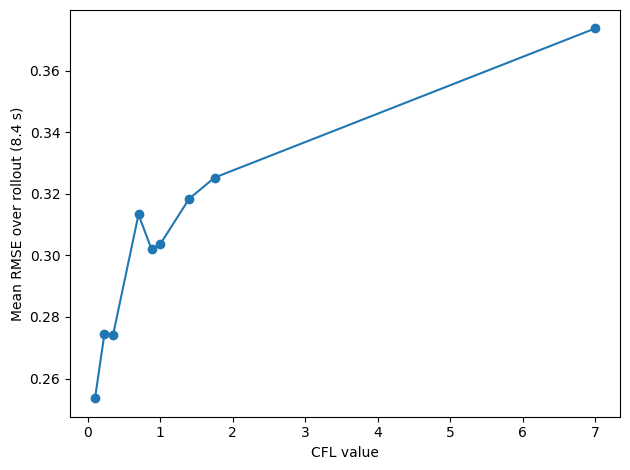

In [57]:
import matplotlib.pyplot as plt

plt.figure()
plt.figure()
plt.plot(df["clf"], df["rmse_mean"], marker="o")
plt.xlabel("CFL value")
plt.ylabel("Mean RMSE over rollout (8.4 s)")
plt.tight_layout()
plt.show()